In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [4]:
data_dir = "./archive (1)"  
transform = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
train_full = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
test_full  = datasets.ImageFolder(os.path.join(data_dir, "test"),  transform=transform)

print("All original classes:")
print(train_full.classes)
selected_folders = [
    "air hockey",
    "baseball",
    "basketball",
    "bowling",
    "boxing",
    "cricket",
    "field hockey",
    "football",
    "swimming",
    "tennis",
]
class_names = selected_folders
print("\nSelected classes:", class_names)
selected_label_ids = {train_full.class_to_idx[f] for f in selected_folders}
print("Selected label ids:", selected_label_ids)
train_indices = [i for i, (_, y) in enumerate(train_full.samples)if y in selected_label_ids]
test_indices = [i for i, (_, y) in enumerate(test_full.samples)if y in selected_label_ids]
train_data = Subset(train_full, train_indices)
test_data  = Subset(test_full,  test_indices)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)
print("Train size:", len(train_data))
print("Test size:", len(test_data))


All original classes:
['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bmx', 'bobsled', 'bowling', 'boxing', 'bull riding', 'bungee jumping', 'canoe slamon', 'cheerleading', 'chuckwagon racing', 'cricket', 'croquet', 'curling', 'disc golf', 'fencing', 'field hockey', 'figure skating men', 'figure skating pairs', 'figure skating women', 'fly fishing', 'football', 'formula 1 racing', 'frisbee', 'gaga', 'giant slalom', 'golf', 'hammer throw', 'hang gliding', 'harness racing', 'high jump', 'hockey', 'horse jumping', 'horse racing', 'horseshoe pitching', 'hurdles', 'hydroplane racing', 'ice climbing', 'ice yachting', 'jai alai', 'javelin', 'jousting', 'judo', 'lacrosse', 'log rolling', 'luge', 'motorcycle racing', 'mushing', 'nascar racing', 'olympic wrestling', 'parallel bar', 'pole climbing', 'pole dancing', 'pole vault', 'polo', 'pommel horse', 'rings', 'ro

In [5]:
def flatten_loader(loader):
    X_list = []
    y_list = []

    for imgs, labels in loader:
        b = imgs.shape[0]
        arr = imgs.numpy().reshape(b, -1) 
        X_list.append(arr)
        y_list.append(labels.numpy())

    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y

X_train, y_train = flatten_loader(train_loader)
X_test, y_test = flatten_loader(test_loader)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (1456, 12288)
Test: (50, 12288)


## PCA + Logistic Regression

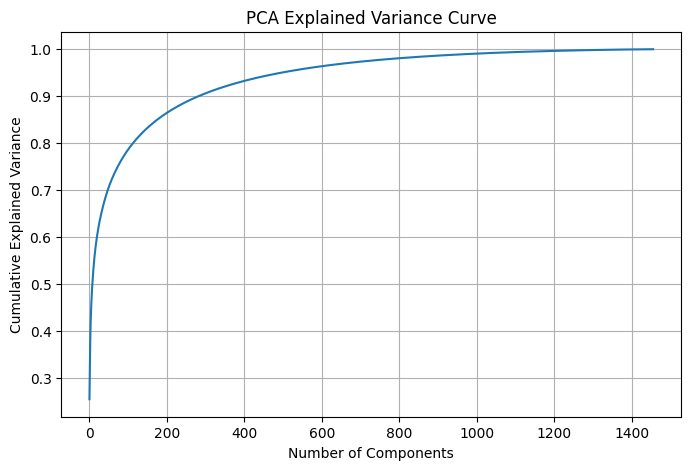

In [6]:
pca_full = PCA().fit(X_train)
explained_var = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(cumvar)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve")
plt.grid(True)
plt.show()

In [7]:
def find_k(threshold):
    """Return the smallest k such that cumulative variance is greater than the threshold"""
    return int(np.argmax(cumvar >= threshold) + 1)

k90 = find_k(0.90)
k95 = find_k(0.95)
k99 = find_k(0.99)
print("k for 90% variance:", k90)
print("k for 95% variance:", k95)
print("k for 99% variance:", k99)
k_values = sorted(list({
    30, 50, 75,           
    k90, k95, k99,            
    max(5, k90 - 50), k90 + 50,
    max(5, k95 - 50), k95 + 50,
    max(5, k99 - 100), k99 + 100}))

print("k values to test:", k_values)


k for 90% variance: 283
k for 95% variance: 497
k for 99% variance: 983
k values to test: [30, 50, 75, 233, 283, 333, 447, 497, 547, 883, 983, 1083]


In [8]:
k_values =  [30, 50, 75, 233, 283, 333, 447, 497, 547, 883]
results = {}

for k in k_values:
    print("\nTesting PCA with k =", k)
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    clf = LogisticRegression(max_iter=3000)
    clf.fit(X_train_pca, y_train)
    preds = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results[k] = {"acc": acc, "f1": f1}
    print(f"Accuracy: {acc:.4f}   F1 Score: {f1:.4f}")



Testing PCA with k = 30
Accuracy: 0.5600   F1 Score: 0.5459

Testing PCA with k = 50
Accuracy: 0.4800   F1 Score: 0.4737

Testing PCA with k = 75
Accuracy: 0.4800   F1 Score: 0.4777

Testing PCA with k = 233
Accuracy: 0.3400   F1 Score: 0.3320

Testing PCA with k = 283
Accuracy: 0.3600   F1 Score: 0.3556

Testing PCA with k = 333
Accuracy: 0.3400   F1 Score: 0.3454

Testing PCA with k = 447
Accuracy: 0.3600   F1 Score: 0.3768

Testing PCA with k = 497
Accuracy: 0.3800   F1 Score: 0.3948

Testing PCA with k = 547
Accuracy: 0.4400   F1 Score: 0.4539

Testing PCA with k = 883
Accuracy: 0.4400   F1 Score: 0.4519


In [9]:
best_k = max(results, key=lambda k: results[k]["f1"])
print("\nBest PCA dimension selected:", best_k)
print("Best Accuracy:", results[best_k]["acc"])
print("Best F1 Score:", results[best_k]["f1"])



Best PCA dimension selected: 30
Best Accuracy: 0.56
Best F1 Score: 0.5458669108669109


In [10]:
print(f"\nTraining FINAL PCA model with k = {best_k}")
final_pca = PCA(n_components=best_k)
X_train_best = final_pca.fit_transform(X_train)
X_test_best = final_pca.transform(X_test)
final_clf = LogisticRegression(max_iter=3000)
final_clf.fit(X_train_best, y_train)
final_preds = final_clf.predict(X_test_best)
final_acc = accuracy_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds, average="macro")
print("\nFINAL MODEL PERFORMANCE")
print("Accuracy:", final_acc)
print("F1 Score (macro):", final_f1)



Training FINAL PCA model with k = 30

FINAL MODEL PERFORMANCE
Accuracy: 0.56
F1 Score (macro): 0.5466749916749917


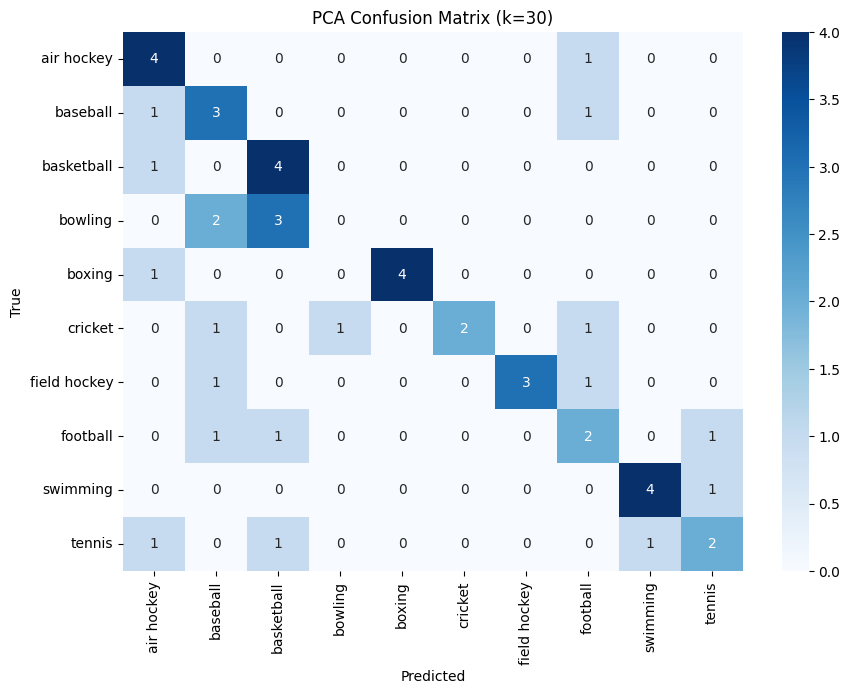

In [11]:
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"PCA Confusion Matrix (k={best_k})")
plt.show()

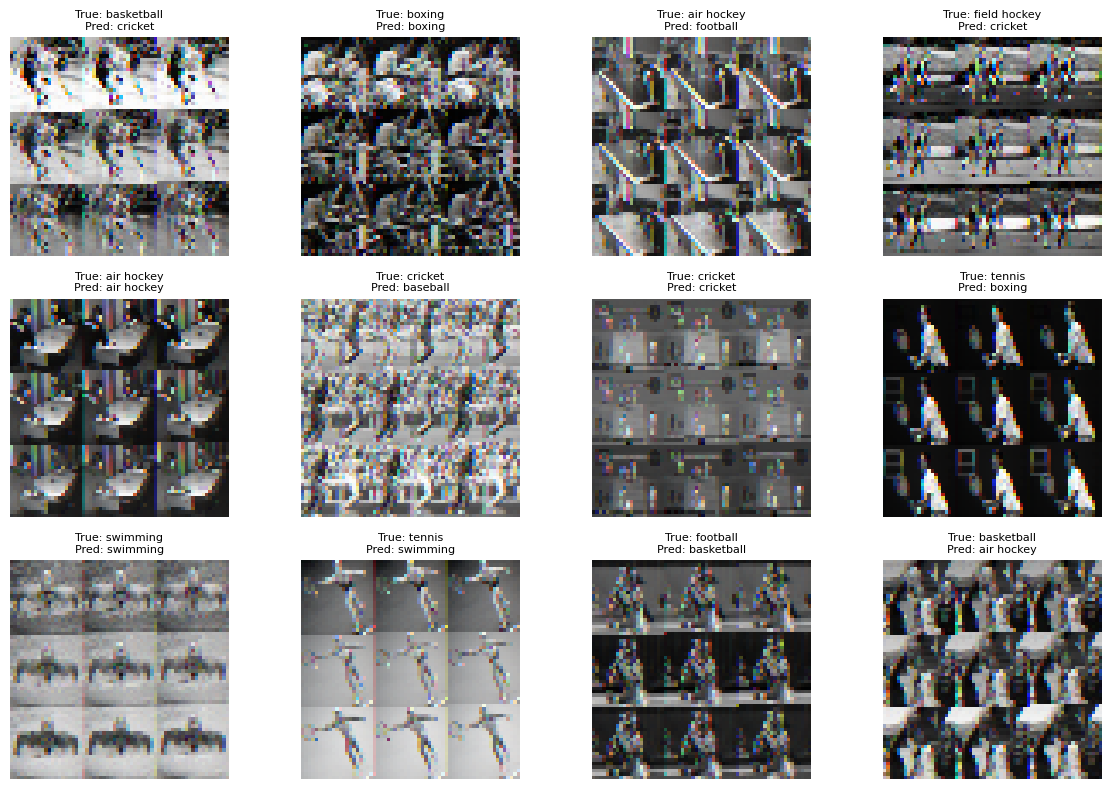

In [24]:
orig_ids = sorted(list(selected_label_ids))      
id_to_idx = {orig: i for i, orig in enumerate(orig_ids)}
img_h, img_w = 64, 64
X_test_pixels = X_test.reshape(-1, img_h, img_w, 3)
indices = np.random.choice(len(X_test_pixels), size=12, replace=False)
plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices):
    img = X_test_pixels[idx]
    img_show = np.clip(img * 255, 0, 255).astype("uint8")
    orig_true = int(y_test[idx])
    orig_pred = int(final_knn_preds[idx])
    true_idx = id_to_idx[orig_true]
    pred_idx = id_to_idx[orig_pred]
    true_label = class_names[true_idx]
    pred_label = class_names[pred_idx]
    plt.subplot(3, 4, i + 1)
    plt.imshow(img_show)
    plt.axis("off")
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=8)

plt.tight_layout()
plt.show()


## PCA + kNN

In [16]:
from sklearn.neighbors import KNeighborsClassifier
print(f"\nTraining PCA for k-NN with k = {best_k}")
pca_knn = PCA(n_components=best_k)
X_train_knn = pca_knn.fit_transform(X_train)
X_test_knn  = pca_knn.transform(X_test)
k_list = [1, 3, 5, 7, 9, 11, 15, 21, 25]
knn_results = {}
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    preds = knn.predict(X_test_knn)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="macro")
    knn_results[k] = {"acc": acc, "f1": f1}
    print(f"k={k:2} → Accuracy={acc:.4f}, F1={f1:.4f}")
best_k_knn = max(knn_results, key=lambda j: knn_results[j]["f1"])
print("\nBest k for k-NN:", best_k_knn)
print("Best Accuracy:", knn_results[best_k_knn]["acc"])
print("Best F1 Score:", knn_results[best_k_knn]["f1"])



Training PCA for k-NN with k = 30
k= 1 → Accuracy=0.3400, F1=0.3059
k= 3 → Accuracy=0.3800, F1=0.3385
k= 5 → Accuracy=0.4400, F1=0.4282
k= 7 → Accuracy=0.4200, F1=0.4116
k= 9 → Accuracy=0.3800, F1=0.3749
k=11 → Accuracy=0.4000, F1=0.4025
k=15 → Accuracy=0.4000, F1=0.4012
k=21 → Accuracy=0.3800, F1=0.3880
k=25 → Accuracy=0.3800, F1=0.3914

Best k for k-NN: 5
Best Accuracy: 0.44
Best F1 Score: 0.4281818181818182


In [17]:
print(f"\nTraining FINAL k-NN model with k={best_k_knn} and PCA={best_k}")
pca_final_knn = PCA(n_components=best_k)
X_train_final = pca_final_knn.fit_transform(X_train)
X_test_final  = pca_final_knn.transform(X_test)
final_knn = KNeighborsClassifier(n_neighbors=best_k_knn)
final_knn.fit(X_train_final, y_train)
final_knn_preds = final_knn.predict(X_test_final)
final_knn_acc = accuracy_score(y_test, final_knn_preds)
final_knn_f1  = f1_score(y_test, final_knn_preds, average="macro")
print("\nFINAL k-NN PERFORMANCE:")
print("Accuracy:", final_knn_acc)
print("F1 Score:", final_knn_f1)



Training FINAL k-NN model with k=5 and PCA=30

FINAL k-NN PERFORMANCE:
Accuracy: 0.46
F1 Score: 0.44261437908496737


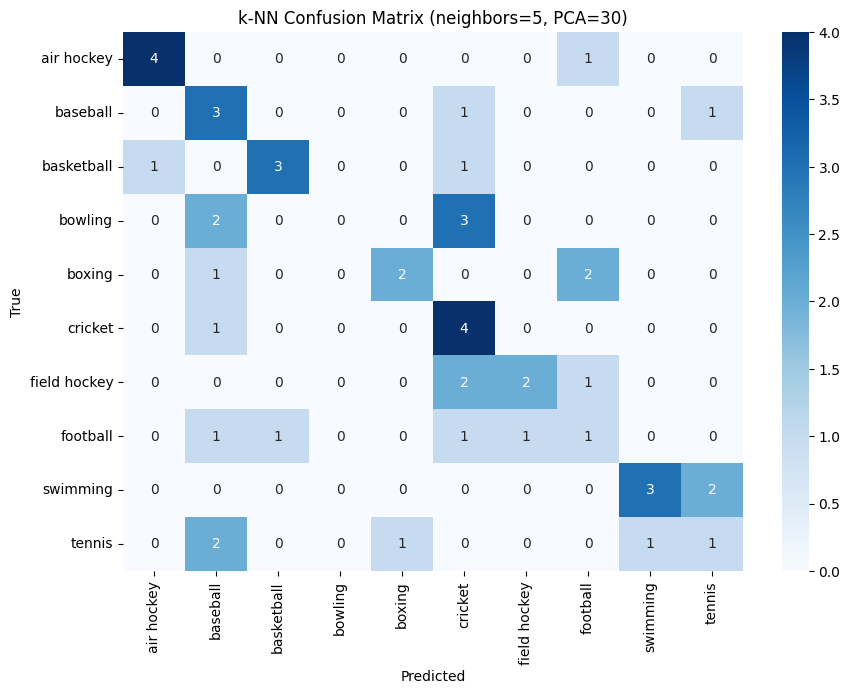

In [19]:
cm_knn = confusion_matrix(y_test, final_knn_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"k-NN Confusion Matrix (neighbors={best_k_knn}, PCA={best_k})")
plt.show()


In [22]:
indices = np.random.choice(len(X_test_pixels), size=12, replace=False)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    img = X_test_pixels[idx]
    img_show = np.clip(img * 255, 0, 255).astype("uint8")

    true_label = class_names[y_test[idx]]
    pred_label = class_names[final_knn_preds[idx]]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_show)
    plt.axis("off")
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=8)

plt.tight_layout()
plt.show()


IndexError: list index out of range

<Figure size 1200x800 with 0 Axes>